In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
df_temp = pd.read_csv('Bengaluru_Ward_Temp_Stats.csv')[['Ward_Name', 'Zone', 'mean']].rename(columns={'mean': 'surface_temp'})
df_urban = pd.read_csv('Bengaluru_Ward_Urban_Stats.csv')[['Ward_Name', 'mean']].rename(columns={'mean': 'urban_index'})
df_veg = pd.read_csv('Bengaluru_Ward_Veg_Stats.csv')[['Ward_Name', 'mean']].rename(columns={'mean': 'veg_index'})
df_water = pd.read_csv('Bengaluru_Ward_Water_Stats.csv')[['Ward_Name', 'mean']].rename(columns={'mean': 'water_index'})
df_barren

# Merge into EDA Master
df = df_temp.merge(df_urban, on='Ward_Name').merge(df_veg, on='Ward_Name').merge(df_water, on='Ward_Name')

df['Zone'] = df['Zone'].str.strip()

# Use a mapping dictionary to unify the spellings
zone_mapping = {
    'Rajarajeswari Nagar': 'Rajarajeshwari Nagar',
    'Dasarahalli': 'Dasarahalli',
    'Bommanahalli': 'Bommanahalli'
}

# Apply the mapping
df['Zone'] = df['Zone'].replace(zone_mapping)
# Verify the result
print("Cleaned Zones:")
print(df['Zone'].unique())

Cleaned Zones:
['East' 'Mahadevapura' 'West' 'Dasarahalli' 'Rajarajeshwari Nagar'
 'Yelahanka' 'Bommanahalli' 'South']


In [109]:
df.describe()

,surface_temp,urban_index,veg_index,water_index
count,198.000000,198.000000,198.000000,198.000000
mean,36.745179,-0.004453,0.123124,-0.138935
std,1.098865,0.016747,0.026398,0.018488
min,34.011624,-0.047910,0.063950,-0.190659
25%,35.938389,-0.015109,0.104023,-0.150080
50%,36.734346,-0.004293,0.120878,-0.136752
75%,37.464310,0.005596,0.141969,-0.125622
max,39.411394,0.037793,0.205407,-0.076691


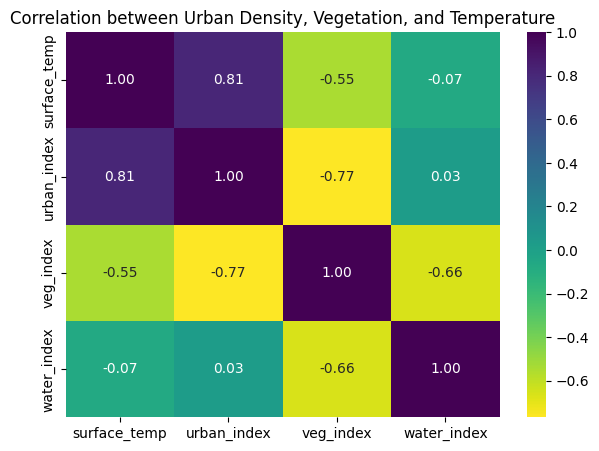

In [107]:
# Correlation Heatmap
plt.figure(figsize=(7,5))
sns.heatmap(df[['surface_temp', 'urban_index', 'veg_index', 'water_index']].corr(), annot=True, cmap='viridis_r', fmt=".2f")
plt.title('Correlation between Urban Density, Vegetation, and Temperature')
plt.show()

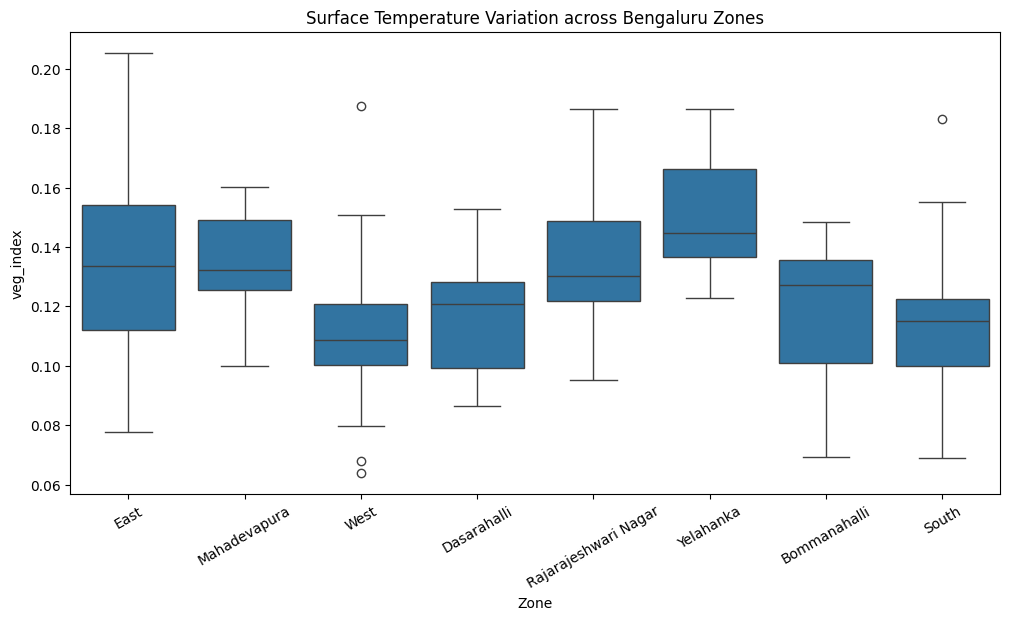

In [95]:
# Green cover Distribution by Zone
plt.figure(figsize=(12, 6))
sns.boxplot(x='Zone', y='veg_index', data=df)
plt.xticks(rotation=30)
plt.title('Surface Temperature Variation across Bengaluru Zones')
plt.show()

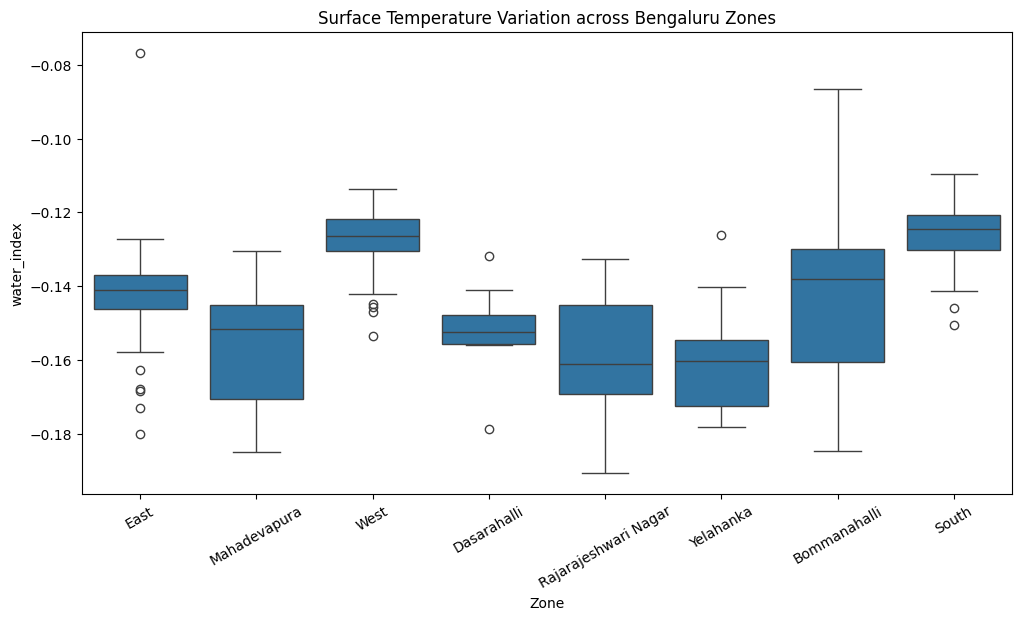

In [96]:
# Water Distribution by Zone
plt.figure(figsize=(12, 6))
sns.boxplot(x='Zone', y='water_index', data=df)
plt.xticks(rotation=30)
plt.title('Surface Temperature Variation across Bengaluru Zones')
plt.show()

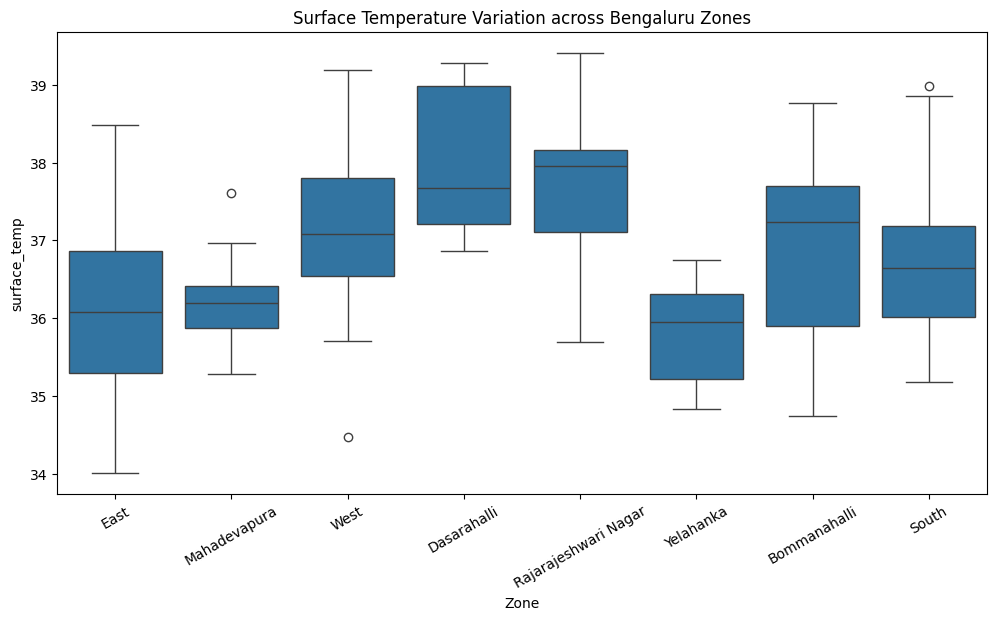

In [97]:
# Temperature Distribution by Zone
plt.figure(figsize=(12, 6))
sns.boxplot(x='Zone', y='surface_temp', data=df)
plt.xticks(rotation=30)
plt.title('Surface Temperature Variation across Bengaluru Zones')
plt.show()

In [98]:
df[df['surface_temp'] > 36].groupby('Zone')['surface_temp'].count()

Zone
Bommanahalli            11
Dasarahalli              8
East                    23
Mahadevapura            11
Rajarajeshwari Nagar    13
South                   34
West                    40
Yelahanka                4
Name: surface_temp, dtype: int64

In [110]:
df[df['Zone'] == 'Dasarahalli']

,Ward_Name,Zone,surface_temp,urban_index,veg_index,water_index
58,Shettihalli,Dasarahalli,36.969429,0.000132,0.152906,-0.178896
59,Mallasandra,Dasarahalli,37.582917,0.011074,0.118351,-0.155579
60,Bagalakunte,Dasarahalli,36.856641,-0.000283,0.127872,-0.153532
61,T Dasarahalli,Dasarahalli,37.759801,0.015342,0.089197,-0.131731
62,Chokkasandra,Dasarahalli,37.291457,-0.000782,0.129122,-0.151318
63,Peenya Industrial Area,Dasarahalli,38.924280,0.011804,0.122968,-0.155960
64,Rajagopal Nagar,Dasarahalli,39.278547,0.019592,0.102626,-0.150103
65,Hegganahalli,Dasarahalli,39.169829,0.027389,0.086603,-0.141113


In [111]:
# Filter for Dasarahalli Case Study
dasarahalli = df[df['Zone'] == 'Dasarahalli'].copy()

# Calculate Heat Stress Priority (High Temp + High Urban / Low Veg); Normalize values to 0-1 for a fair score
dasarahalli['temp_norm'] = (dasarahalli['surface_temp'] - dasarahalli['surface_temp'].min()) / (dasarahalli['surface_temp'].max() - dasarahalli['surface_temp'].min())
dasarahalli['heat_priority'] = dasarahalli['temp_norm'] + dasarahalli['urban_index'] - dasarahalli['veg_index']

In [112]:
dasarahalli

,Ward_Name,Zone,surface_temp,urban_index,veg_index,water_index,temp_norm,heat_priority
58,Shettihalli,Dasarahalli,36.969429,0.000132,0.152906,-0.178896,0.046570,-0.106204
59,Mallasandra,Dasarahalli,37.582917,0.011074,0.118351,-0.155579,0.299878,0.192600
60,Bagalakunte,Dasarahalli,36.856641,-0.000283,0.127872,-0.153532,0.000000,-0.128154
61,T Dasarahalli,Dasarahalli,37.759801,0.015342,0.089197,-0.131731,0.372913,0.299057
62,Chokkasandra,Dasarahalli,37.291457,-0.000782,0.129122,-0.151318,0.179534,0.049630
63,Peenya Industrial Area,Dasarahalli,38.924280,0.011804,0.122968,-0.155960,0.853724,0.742559
64,Rajagopal Nagar,Dasarahalli,39.278547,0.019592,0.102626,-0.150103,1.000000,0.916967
65,Hegganahalli,Dasarahalli,39.169829,0.027389,0.086603,-0.141113,0.955110,0.895897


In [113]:
target_ward = dasarahalli.sort_values('heat_priority', ascending=False).iloc[0]
print(f"Target Ward for Pocket Forest: {target_ward['Ward_Name']}")

Target Ward for Pocket Forest: Rajagopal Nagar


In [114]:
target_ward

Ward_Name        Rajagopal Nagar
Zone                 Dasarahalli
surface_temp           39.278547
urban_index             0.019592
veg_index               0.102626
water_index            -0.150103
temp_norm                    1.0
heat_priority           0.916967
Name: 64, dtype: object

In [115]:
import json
from shapely.geometry import shape, Point

# Load bare land points
bare_land = pd.read_csv('Bare_Land_Coordinates_for_ML.csv')

# Convert the .geo string of our target ward into a shapely object
ward_boundary_json = json.loads(target_ward['.geo'])
ward_polygon = shape(ward_boundary_json)

def is_inside(row):
    # Parse coordinates from the .geo column in bare_land (format: [long, lat])
    coords = json.loads(row['.geo'])['coordinates']
    point = Point(coords[0], coords[1])
    return ward_polygon.contains(point)

# Find bare land points physically located inside the target ward
planting_sites = bare_land[bare_land.apply(is_inside, axis=1)]

print(f"Found {len(planting_sites)} potential pocket forest sites in {target_ward['Ward_Name']}.")

KeyError: '.geo'